In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!pip -q install -U bitsandbytes accelerate transformers trl peft

In [2]:
# ✅ 1. Đăng nhập Hugging Face
from huggingface_hub import login
login(new_session=False)  #

In [3]:
from datasets import load_dataset

# ======= 3️⃣ Load dataset =======
dataset = load_dataset("8Opt/vietnamese-summarization-dataset-0001")
data = dataset["train"]

print("Tổng số mẫu gốc:", len(data))

# ======= ✂️ Lấy đúng 5000 mẫu =======
data = data.select(range(5000))

print("Số mẫu sau khi lấy 5k:", len(data))


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/30.2M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/3.89M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15620 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1952 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1953 [00:00<?, ? examples/s]

Tổng số mẫu gốc: 15620
Số mẫu sau khi lấy 5k: 5000


In [4]:

print("Tổng số mẫu train:", len(data))

# In 3 sample đầu tiên
for i in range(3):
    sample = data[i]
    print(f"\n--- Sample {i+1} ---")
    for col_name, value in sample.items():
        # Nếu giá trị là string dài, chỉ in 300 ký tự đầu
        if isinstance(value, str) and len(value) > 300:
            print(f"{col_name}: {value[:300]} ...")
        else:
            print(f"{col_name}: {value}")

Tổng số mẫu train: 5000

--- Sample 1 ---
document: Lá N của cây N lô hội N chứa V đầy A chất N gel N và bạn N có thể hái V mỗi khi N cần V . Nên V để khi N nào dùng V mới hái V . Cắt N một nhánh N từ cây lô hội N và vắt V hoặc múc V phần N gel V trong suốt A bên N trong N ra V . Nếu N thu hoạch V nhiều A , bạn N có thể cắt V đôi lá N cây N lô hội N  ...
summary: Lô hội, với chất gel giàu dưỡng chất, có thể sử dụng để chữa lành các vấn đề về da như bỏng nắng, gàu và da khô. Bạn có thể sử dụng lá lô hội tươi để lấy gel, bôi trực tiếp lên da bị tổn thương. Lưu ý, gel lô hội không nên bôi lên vùng da bị chảy máu hoặc tổn thương nặng. Lô hội cũng có thể được dùn ...
keywords: ['Lô hội', 'gel', 'bỏng nắng', 'gàu', 'herpes', 'da khô']

--- Sample 2 ---
document: Tối 6/11 , trong lúc ra vườn rau muống cách nhà chừng 50 m , ông Nguyễn Dương Liễu ( 50 tuổi , xã Thanh Thuỷ , Thanh Chương , Nghệ An ) thấy con rùa lấm lem bùn đất nằm ở lùm cây .Sau khi tắm rửa , con rùa cân được 16 kg .Phần bụng r

In [5]:
from datasets import DatasetDict

# Tách 10% làm validation, 10% làm test
split_val_test = data.train_test_split(test_size=0.2, seed=42)  # 20% = val+test
val_test = split_val_test['test'].train_test_split(test_size=0.5, seed=42)  # chia đều val & test

dataset = DatasetDict({
    'train': split_val_test['train'],
    'validation': val_test['train'],
    'test': val_test['test']
})

print(dataset)


DatasetDict({
    train: Dataset({
        features: ['document', 'summary', 'keywords'],
        num_rows: 4000
    })
    validation: Dataset({
        features: ['document', 'summary', 'keywords'],
        num_rows: 500
    })
    test: Dataset({
        features: ['document', 'summary', 'keywords'],
        num_rows: 500
    })
})


In [6]:
from transformers import AutoTokenizer
from transformers import AutoModelForSeq2SeqLM

model_name = "VietAI/vit5-base" # hoặc "vinai/bartpho-summarization"
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

max_input_length = 1024
max_target_length = 512



config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

2025-11-26 08:55:14.288168: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764147314.526807     117 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764147314.594316     117 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

model.safetensors:   0%|          | 0.00/904M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/820k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

In [8]:
def preprocess_function(batch):
    # Dataset chỉ có: document, summary (keywords bỏ)
    inputs = batch["document"]

    model_inputs = tokenizer(
        inputs,
        max_length=max_input_length,
        truncation=True,
    )

    labels = tokenizer(
        batch["summary"],
        max_length=max_target_length,
        truncation=True
    ).input_ids

    model_inputs["labels"] = labels
    return model_inputs

In [11]:
tokenized_dataset = dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=["document", "summary", "keywords"]  # bỏ cột thừa
)

print(tokenized_dataset)


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 4000
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 500
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 500
    })
})


In [13]:
# Kiểm tra tokenized sample đầu tiên
sample = tokenized_dataset["train"][0]

print("Các key có trong tokenized sample:", sample.keys())

# In vài token đầu để kiểm tra
print("\nInput_ids (đầu 20 tokens):", sample["input_ids"][:20])
print("Attention_mask (đầu 20 tokens):", sample["attention_mask"][:20])
print("Labels (đầu 20 tokens):", sample["labels"][:20])

Các key có trong tokenized sample: dict_keys(['input_ids', 'attention_mask', 'labels'])

Input_ids (đầu 20 tokens): [174, 239, 74, 290, 118, 1113, 335, 872, 942, 221, 424, 900, 786, 6436, 2516, 129, 2994, 401, 39, 6436]
Attention_mask (đầu 20 tokens): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Labels (đầu 20 tokens): [2601, 1311, 118, 1184, 861, 631, 872, 942, 6436, 2516, 674, 39, 6436, 2516, 129, 2994, 401, 180, 314, 219]


In [14]:
print("== Input Text ==")
print(tokenizer.decode(sample["input_ids"], skip_special_tokens=True))

print("\n== Summary ==")
print(tokenizer.decode(sample["labels"], skip_special_tokens=True))

print("\n== Attention Mask (độ dài):", len(sample["attention_mask"]))
print("== Input IDs (đầu 20):", sample["input_ids"][:20])

== Input Text ==
Để làm được điều này bạn phải phân biệt sự khác nhau giữa nốt ruồi không điển hình và nốt ruồi thường. Nốt ruồi không điển hình, còn gọi là bớt loạn sản, xuất hiện phổ biến ở ngực và lưng. Chúng thường có đường kính lớn hơn 6 mm và có ít nhất ba sắc của màu nâu hoặc đen. Nốt ruồi không điển hình trông khác nốt ruồi thường vì nó có bờ không đều, đa số đều nhô lên ở chính giữa. Chúng có nguy cơ phát triển thành ung thư da cao hơn. Nốt ruồi thường có đường kính dưới 6 mm, không có nhiều hơn hai sắc màu, có bờ đều và rõ nét trên da. Đôi khi nốt ruồi thường phát triển thành không điển hình nếu các tế bào sắc tố sinh sản bất thường. Tàn nhang khác với nốt ruồi, chúng không phát sinh từ sự gia tăng của các tế bào mang sắc tố, mà hình thành từ sự tập hợp của một số tế bào mang sắc tố tạo nên đặc điểm như tàn nhang. Tàn nhang có màu sáng hơn và nhỏ hơn mụn ruồi, phẳng mặt và thường xuất hiện trên mặt, ngực và bắp tay. Để phát hiện sớm ung thư da bạn cần tự mình xem xét mụn ruồi

In [15]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,  # rất quan trọng với T5/BART để xử lý label padding đúng
    return_tensors="pt"
)


In [16]:
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir="./output_loss_only",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    learning_rate=2e-5,

    eval_strategy="steps",
    eval_steps=100,                  
    logging_strategy="steps",
    logging_steps=50,               

    save_strategy="no",              
    predict_with_generate=True,    
    report_to="none",                
    fp16=True
)


In [17]:
from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    tokenizer=tokenizer,               # vẫn giữ để dùng decode, compute_metrics
    data_collator=data_collator       # ✅ THAY VÌ dùng tokenizer nội bộ
)


/tmp/ipykernel_117/2783352374.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


In [18]:
trainer.train()

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss,Validation Loss
100,1.758700,1.506975
200,1.607400,1.430090
300,1.499100,1.396066
400,1.481500,1.371804
500,1.450200,1.355723
600,1.385700,1.349042
700,1.399000,1.342558


TrainOutput(global_step=750, training_loss=1.5430754699707032, metrics={'train_runtime': 2584.0712, 'train_samples_per_second': 4.644, 'train_steps_per_second': 0.29, 'total_flos': 1.099681373435904e+16, 'train_loss': 1.5430754699707032, 'epoch': 3.0})

In [19]:
trainer.save_model("./output_loss_only")           # lưu model weights
tokenizer.save_pretrained("./output_loss_only")    # lưu tokenizer


('./output_loss_only/tokenizer_config.json',
 './output_loss_only/special_tokens_map.json',
 './output_loss_only/spiece.model',
 './output_loss_only/added_tokens.json',
 './output_loss_only/tokenizer.json')

In [20]:
!pip -q install evaluate
!pip -q install bert_score
!pip install --upgrade openai

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.5 MB/s eta 0:00:00


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.7 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: openai
    Found existing installation: openai 2.7.1
    Uninstalling openai-2.7.1:
      Successfully uninstalled openai-2.7.1


In [21]:
import openai
import os
import json
import time

In [ ]:
client = openai.OpenAI(
    api_key=os.environ.get("OPENAI_API_KEY"),
)

In [23]:
def generate_synthetic_summary(document):
    prompt = f"""
Bạn là mô hình tóm tắt tiếng Việt.
Hãy viết một bản tóm tắt rõ ràng, xúc tích, giữ đầy đủ ý quan trọng.

Văn bản:
{document}

Yêu cầu:
- Viết tóm tắt 3–5 câu
- Không thêm thông tin mới
- Không được suy diễn
"""
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "Bạn chuyên tạo tóm tắt tiếng Việt chất lượng cao."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.2
    )

    return response.choices[0].message.content.strip()


In [27]:
from tqdm import tqdm


synthetic_document = []
synthetic_summary = []

samples = dataset["train"].select(range(1000))  # ví dụ 100 mẫu đầu

for sample in tqdm(samples, desc="Generating synthetic summaries"):
    document = sample["document"]
    summary = generate_synthetic_summary(document)

    synthetic_document.append(document)
    synthetic_summary.append(summary)

Generating synthetic summaries: 100%|██████████| 1000/1000 [55:11<00:00,  3.31s/it] 


In [32]:
import pandas as pd
#3️⃣ Tạo DataFrame
# ---------------------------
synthetic_df = pd.DataFrame({
    "document": synthetic_document,
    "summary": synthetic_summary
})

print(synthetic_df.head())


                                            document  \
0  Để làm được điều này bạn phải phân biệt sự khá...   
1  Khoảng 17h30 ngày 15/4 , Khoa cấp cứu , Bệnh v...   
2  Con gấu do chủ nuôi ở thị trấn Sìn Hồ tự nguyệ...   
3  Đàm phán nhằm khôi phục hiệp định TPP đã gặp k...   
4  Cùng A bị V đưa V ra V xét xử V về nhóm N tội ...   

                                             summary  
0  Nốt ruồi không điển hình, hay bớt loạn sản, có...  
1  Vào khoảng 17h30 ngày 15/4, Bệnh viện Việt Nam...  
2  Con gấu tên Rocky, được nuôi làm cảnh trong 12...  
3  Đàm phán khôi phục hiệp định TPP gặp khó khăn ...  
4  Tòa án nhân dân thành phố Hòa Bình đã xét xử v...  


In [34]:
from datasets import Dataset

synthetic_dataset = Dataset.from_pandas(synthetic_df)
print("Synthetic samples:", len(synthetic_dataset))


Synthetic samples: 1000


In [35]:
tokenized_synthetic = synthetic_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=["document", "summary"]
)


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [36]:
from datasets import concatenate_datasets

aug_train_dataset = concatenate_datasets([
    tokenized_dataset["train"],
    tokenized_synthetic
])

print("Train gốc:", len(tokenized_dataset["train"]))
print("Synthetic:", len(tokenized_synthetic))
print("Tổng train augmented:", len(aug_train_dataset))


Train gốc: 4000
Synthetic: 1000
Tổng train augmented: 5000


In [37]:
training_args_2 = Seq2SeqTrainingArguments(
    output_dir="./output_augmented",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    learning_rate=2e-5,

    eval_strategy="steps",
    eval_steps=100,                  
    logging_strategy="steps",
    logging_steps=50,               

    save_strategy="no",              
    predict_with_generate=True,    
    report_to="none",
    fp16=True,
)



In [38]:

trainer_2 = Seq2SeqTrainer(
    model=model,
    args=training_args_2,
    train_dataset=aug_train_dataset,
    eval_dataset=tokenized_dataset["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator
)


/tmp/ipykernel_117/4205979381.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer_2 = Seq2SeqTrainer(


In [39]:
trainer_2.train()




/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss,Validation Loss
100,1.375800,1.347389
200,1.357600,1.331278
300,1.350500,1.318408
400,1.268100,1.304108
500,1.260000,1.296339
600,1.235000,1.288043
700,1.194900,1.281325
800,1.191600,1.281863
900,1.180300,1.279478


TrainOutput(global_step=939, training_loss=1.2705412103979987, metrics={'train_runtime': 3253.1114, 'train_samples_per_second': 4.611, 'train_steps_per_second': 0.289, 'total_flos': 1.38390200239104e+16, 'train_loss': 1.2705412103979987, 'epoch': 3.0})

In [40]:
trainer_2.save_model("./model_summarization_augmented")
tokenizer.save_pretrained("./model_summarization_augmented")

('./model_summarization_augmented/tokenizer_config.json',
 './model_summarization_augmented/special_tokens_map.json',
 './model_summarization_augmented/spiece.model',
 './model_summarization_augmented/added_tokens.json',
 './model_summarization_augmented/tokenizer.json')

In [41]:
# ===== Load model 1 =====
model1 = AutoModelForSeq2SeqLM.from_pretrained("./output_loss_only")
tokenizer1 = AutoTokenizer.from_pretrained("./output_loss_only")

model1.eval()

T5ForConditionalGeneration(
  (shared): Embedding(36096, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(36096, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=768, out_features=3072, bias=False)
              (wo): Linear(in_features=3072, out_features=768, bias=False)
              (dropout): Dro

In [42]:
# ===== Load model 2 =====
model2 = AutoModelForSeq2SeqLM.from_pretrained("./model_summarization_augmented")
tokenizer2 = AutoTokenizer.from_pretrained("./model_summarization_augmented")

model2.eval()

T5ForConditionalGeneration(
  (shared): Embedding(36096, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(36096, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=768, out_features=3072, bias=False)
              (wo): Linear(in_features=3072, out_features=768, bias=False)
              (dropout): Dro

In [43]:
# ===== Hàm summarize wrapper =====
def summarize_model1(text, max_input_length=1024, max_output_length=256, min_output_length=80):
    inputs = tokenizer1(text, return_tensors="pt", truncation=True, max_length=max_input_length)
    output_ids = model1.generate(
        **inputs,
        max_length=max_output_length,
        min_length=min_output_length,
        num_beams=5,
        no_repeat_ngram_size=3,
        length_penalty=1.0,
        early_stopping=True
    )
    return tokenizer1.decode(output_ids[0], skip_special_tokens=True)

def summarize_model2(text, max_input_length=1024, max_output_length=256, min_output_length=80):
    inputs = tokenizer2(text, return_tensors="pt", truncation=True, max_length=max_input_length)
    output_ids = model2.generate(
        **inputs,
        max_length=max_output_length,
        min_length=min_output_length,
        num_beams=5,
        no_repeat_ngram_size=3,
        length_penalty=1.0,
        early_stopping=True
    )
    return tokenizer2.decode(output_ids[0], skip_special_tokens=True)

In [47]:
# ===== Test inference =====
text = """
Từ 1/7/2026, Hà Nội sẽ cấm xe máy chạy xăng lưu thông theo khung giờ hoặc trong những khu vực xác định thuộc vành đai 1, khi vùng phát thải thấp đầu tiên của thành phố được áp dụng thí điểm.

Chiều 26/11, với 100% đại biểu có mặt tán thành, HĐND TP Hà Nội thông qua Nghị quyết về vùng phát thải thấp theo Luật Thủ đô 2024. Đây là khu vực được xác định nhằm hạn chế phương tiện gây ô nhiễm môi trường, ưu tiên các loại xe sử dụng năng lượng sạch.

Theo Nghị quyết, tại vùng phát thải thấp, xe môtô và xe gắn máy chạy xăng sẽ bị cấm lưu thông tùy theo từng khung giờ hoặc từng khu vực; xe hành nghề trên nền tảng ứng dụng cũng không được phép hoạt động. Với ôtô không đạt tiêu chuẩn khí thải mức 4, thành phố sẽ hạn chế và tiến tới cấm vào các khu vực này theo thời điểm hoặc tuyến đường cụ thể.

Thành phố đưa ra lộ trình chuyển đổi xanh cho phương tiện kinh doanh vận tải dùng nhiên liệu hóa thạch. Xe máy phải hoàn tất chuyển đổi trước năm 2030, còn taxi từ 1/7/2026 chỉ được đầu tư mới hoặc thay thế bằng phương tiện chạy điện hoặc dùng năng lượng xanh. Từ 1/1/2035, UBND thành phố sẽ quyết định phạm vi và thời điểm hạn chế lưu thông các phương tiện đường bộ tùy theo điều kiện thực tế.
"""

In [48]:
print("Model1 summary:", summarize_model1(text))


Model1 summary: Vào chiều 26/11, HĐND TP Hà Nội thông qua Nghị quyết về vùng phát thải thấp theo Luật Thủ đô 2024. Nghị quyết nhấn mạnh tầm quan trọng của việc hạn chế phương tiện gây ô nhiễm môi trường, ưu tiên các loại xe sử dụng năng lượng sạch và ưu tiên sử dụng nhiên liệu hóa thạch. Theo Nghị quyết, xe môtô và xe gắn máy sẽ bị cấm lưu thông theo khung giờ hoặc khu vực. Thành phố đưa ra lộ trình chuyển đổi xanh cho các phương tiện kinh doanh vận tải, trong khi taxi phải hoàn tất chuyển đổi trước năm 2030.


In [49]:
print("Model2 summary:", summarize_model2(text))

Model2 summary: Vào ngày 26/11, HĐND TP Hà Nội thông qua Nghị quyết về vùng phát thải thấp theo Luật Thủ đô 2024. Nghị quyết nhấn mạnh tầm quan trọng của việc hạn chế phương tiện gây ô nhiễm môi trường và ưu tiên các loại xe sử dụng năng lượng sạch. Theo Nghị quyết, xe môtô và xe gắn máy chạy xăng sẽ bị cấm lưu thông tùy theo khung giờ hoặc khu vực. Thành phố cũng đưa ra lộ trình chuyển đổi xanh cho phương tiện vận tải dùng nhiên liệu hóa thạch. Từ 1/7/2026, xe máy sẽ được đầu tư mới hoặc thay thế bằng phương tiện chạy điện.


In [50]:
import pandas as pd

# Giả sử test_dataset là Dataset của HF, đã có 'document' và 'summary'
test_dataset = dataset['test']  # thêm dòng này trước khi dùng

num_samples = 100
docs = test_dataset["document"][:num_samples]
refs = test_dataset["summary"][:num_samples]




In [51]:
pred_summaries_model1 = []
for doc in tqdm(docs,desc="Generating synthetic summaries"):
    summary = summarize_model1(doc, max_input_length=1024, max_output_length=256, min_output_length=120)
    pred_summaries_model1.append(summary)

Generating synthetic summaries: 100%|██████████| 100/100 [24:19<00:00, 14.60s/it]


In [52]:
# ===== Dự đoán với Model 2 =====
pred_summaries_model2 = []
for doc in tqdm(docs,desc="Generating synthetic summaries"):
    summary = summarize_model2(doc, max_input_length=1024, max_output_length=256, min_output_length=120)
    pred_summaries_model2.append(summary)


Generating synthetic summaries: 100%|██████████| 100/100 [24:18<00:00, 14.58s/it]


In [53]:
# ===== Tạo DataFrame chuẩn bị đánh giá =====
df_model1 = pd.DataFrame({
    "document": docs,
    "reference_summary": refs,
    "pred_summary_model1": pred_summaries_model1
})

In [54]:

df_model2 = pd.DataFrame({
    "document": docs,
    "reference_summary": refs,
    "pred_summary_model2": pred_summaries_model2
})

In [55]:


# In thử 3 dòng đầu
print(df_model1.head(3))
print(df_model2.head(3))

                                            document  \
0  Khuấy tan V dung dịch N và súc miệng V nhiều A...   
1  Cụ thể , tại văn bản số 3900 / BYT - BM - TE c...   
2  Phân bố\nMèo ri có mặt ở Ai Cập, Tây Á, Trung ...   

                                   reference_summary  \
0  Bài viết cung cấp các phương pháp điều trị lở ...   
1  Vụ Sức khoẻ bà mẹ - trẻ em, Bộ Y tế đã yêu cầu...   
2  Mèo ri, một loài mèo hoang, được tìm thấy ở nh...   

                                 pred_summary_model1  
0  Bài viết này cung cấp hướng dẫn chi tiết về cá...  
1  Vào ngày 5/7, Vụ Sức khoẻ bà mẹ - trẻ em, Bộ Y...  
2  Bài viết này cung cấp thông tin về Mèo ri ở Ai...  
                                            document  \
0  Khuấy tan V dung dịch N và súc miệng V nhiều A...   
1  Cụ thể , tại văn bản số 3900 / BYT - BM - TE c...   
2  Phân bố\nMèo ri có mặt ở Ai Cập, Tây Á, Trung ...   

                                   reference_summary  \
0  Bài viết cung cấp các phương pháp điều trị lở 

In [56]:
import evaluate

bertscore = evaluate.load("bertscore")
rouge = evaluate.load("rouge")

In [57]:
# ===== Số lượng sample test =====
num_samples = 100
refs = test_dataset["summary"][:num_samples]

# ===== ROUGE =====
rouge_model1 = rouge.compute(predictions=pred_summaries_model1, references=refs)
rouge_model2 = rouge.compute(predictions=pred_summaries_model2, references=refs)

# Trung bình ROUGE F1
avg_rouge_model1 = {k: v for k, v in rouge_model1.items()}
avg_rouge_model2 = {k: v for k, v in rouge_model2.items()}

# ===== BERTScore =====
bertscore_model1 = bertscore.compute(predictions=pred_summaries_model1, references=refs, lang="vi")
bertscore_model2 = bertscore.compute(predictions=pred_summaries_model2, references=refs, lang="vi")

# Trung bình BERTScore: chuyển tất cả về float
avg_bertscore_model1 = {k: float(sum(v))/len(v) for k, v in bertscore_model1.items() if k in ["precision","recall","f1"]}
avg_bertscore_model2 = {k: float(sum(v))/len(v) for k, v in bertscore_model2.items() if k in ["precision","recall","f1"]}


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

In [58]:
# ===== Tạo bảng so sánh =====
df_compare = pd.DataFrame({
    "Metric": ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore Precision", "BERTScore Recall", "BERTScore F1"],
    "Model 1": [
        avg_rouge_model1.get("rouge1", 0),
        avg_rouge_model1.get("rouge2", 0),
        avg_rouge_model1.get("rougeL", 0),
        avg_bertscore_model1["precision"],
        avg_bertscore_model1["recall"],
        avg_bertscore_model1["f1"]
    ],
    "Model 2": [
        avg_rouge_model2.get("rouge1", 0),
        avg_rouge_model2.get("rouge2", 0),
        avg_rouge_model2.get("rougeL", 0),
        avg_bertscore_model2["precision"],
        avg_bertscore_model2["recall"],
        avg_bertscore_model2["f1"]
    ]
})

print(df_compare)

                Metric   Model 1   Model 2
0              ROUGE-1  0.776490  0.777139
1              ROUGE-2  0.471083  0.475780
2              ROUGE-L  0.457189  0.471036
3  BERTScore Precision  0.793515  0.797449
4     BERTScore Recall  0.795191  0.800937
5         BERTScore F1  0.794231  0.799060


In [59]:
import json
import pandas as pd
from tqdm import tqdm

In [60]:
def evaluate_summarization_gpt4o_vi(document, reference, prediction):
    system_prompt = """
Bạn là chuyên gia đánh giá tóm tắt văn bản.
Đánh giá 4 tiêu chí (1–10):
1️⃣ Fluency: Lưu loát & mạch lạc.
2️⃣ Relevance: Liên quan & hữu ích.
3️⃣ Faithfulness: Độ trung thực với nội dung gốc.
4️⃣ Conciseness: Ngắn gọn, súc tích.

Phải phản hồi **JSON hợp lệ**:
{
  "fluency": <điểm>,
  "relevance": <điểm>,
  "faithfulness": <điểm>,
  "conciseness": <điểm>,
  "average": <điểm>
}
"""
    evaluation_prompt = f"""
Văn bản gốc:
{document}

Tóm tắt chuẩn (reference):
{reference}

Tóm tắt mô hình (prediction):
{prediction}
"""
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": evaluation_prompt}
            ],
            response_format={"type": "json_object"}
        )
        # Lấy JSON từ GPT
        raw_text = response.choices[0].message.content.strip()
        result = json.loads(raw_text)
        # Ép kiểu float
        for k in result:
            result[k] = float(result[k])
    except Exception as e:
        print("⚠️ Lỗi API hoặc lỗi JSON:", e)
        result = {k: None for k in ["fluency","relevance","faithfulness","conciseness","average"]}
    return result

In [61]:
num_samples = 100
docs = test_dataset["document"][:num_samples]
refs = test_dataset["summary"][:num_samples]

In [62]:
evals_model1 = []
evals_model2 = []

print("🔹 Evaluating Model 1")
for i in tqdm(range(num_samples)):
    eval_result = evaluate_summarization_gpt4o_vi(
        document=docs[i],
        reference=refs[i],
        prediction=pred_summaries_model1[i]
    )
    evals_model1.append(eval_result)

🔹 Evaluating Model 1


100%|██████████| 100/100 [02:31<00:00,  1.51s/it]


In [63]:
for i in tqdm(range(num_samples), desc="Evaluating Model 2"):
    eval_result = evaluate_summarization_gpt4o_vi(
        document=docs[i],
        reference=refs[i],
        prediction=pred_summaries_model2[i]
    )
    evals_model2.append(eval_result)

Evaluating Model 2: 100%|██████████| 100/100 [02:24<00:00,  1.45s/it]


In [68]:
# Chuyển sang DataFrame
df_gpt_eval = pd.DataFrame({
    "document": docs,
    "reference_summary": refs,
    "pred_model1": pred_summaries_model1,
    "pred_model2": pred_summaries_model2,
    "eval_model1": evals_model1,
    "eval_model2": evals_model2
})

In [69]:
# Tách riêng các cột điểm cho dễ tính trung bình
for criterion in ["fluency","relevance","faithfulness","conciseness","average"]:
    df_gpt_eval[f"{criterion}_model1"] = [e[criterion] for e in evals_model1]
    df_gpt_eval[f"{criterion}_model2"] = [e[criterion] for e in evals_model2]


In [70]:
# Tính điểm trung bình tổng thể cho 2 model
avg_scores_model1 = df_gpt_eval[[f"{c}_model1" for c in ["fluency","relevance","faithfulness","conciseness","average"]]].mean()
avg_scores_model2 = df_gpt_eval[[f"{c}_model2" for c in ["fluency","relevance","faithfulness","conciseness","average"]]].mean()

In [71]:
df_avg_gpt = pd.DataFrame({
    "Metric": ["Fluency","Relevance","Faithfulness","Conciseness","Average"],
    "Model 1": avg_scores_model1.values,
    "Model 2": avg_scores_model2.values
})

print(df_avg_gpt)

         Metric  Model 1  Model 2
0       Fluency   7.6100    7.690
1     Relevance   8.3500    8.480
2  Faithfulness   7.2200    7.430
3   Conciseness   6.5900    6.640
4       Average   7.4375    7.555


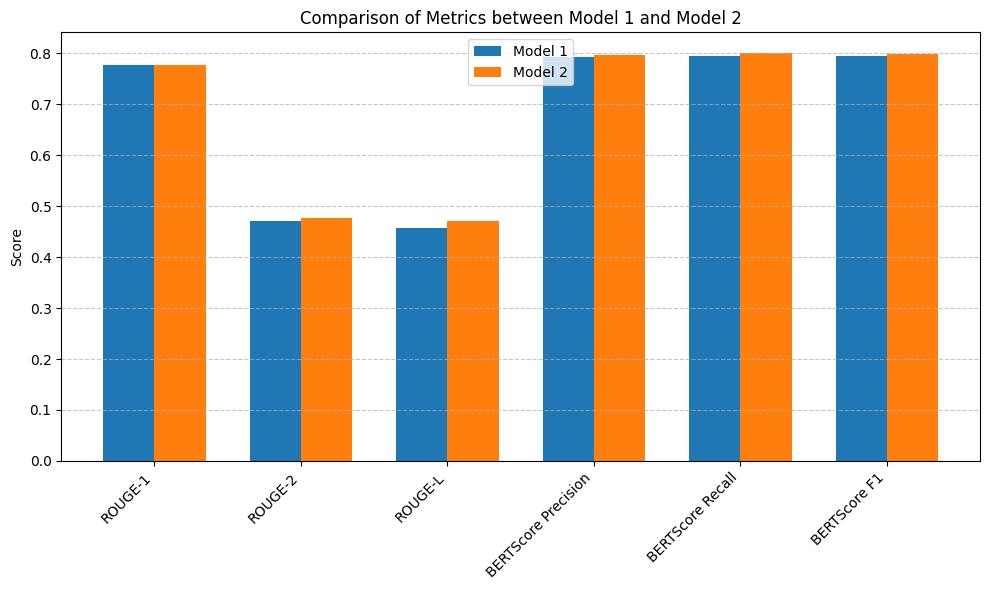

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

# Giả sử đây là DataFrame của bạn
data = {
    "Metric": ["ROUGE-1", "ROUGE-2", "ROUGE-L",
               "BERTScore Precision", "BERTScore Recall", "BERTScore F1"],
    "Model 1": [0.776490, 0.471083, 0.457189, 0.793515, 0.795191, 0.794231],
    "Model 2": [0.777139, 0.475780, 0.471036, 0.797449, 0.800937, 0.799060]
}

df = pd.DataFrame(data)

# ----- Vẽ biểu đồ grouped bar -----
metrics = df["Metric"]
x = range(len(metrics))
width = 0.35  # độ rộng cột

fig, ax = plt.subplots(figsize=(10,6))
ax.bar([i - width/2 for i in x], df["Model 1"], width, label="Model 1")
ax.bar([i + width/2 for i in x], df["Model 2"], width, label="Model 2")

ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=45, ha="right")
ax.set_ylabel("Score")
ax.set_title("Comparison of Metrics between Model 1 and Model 2")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


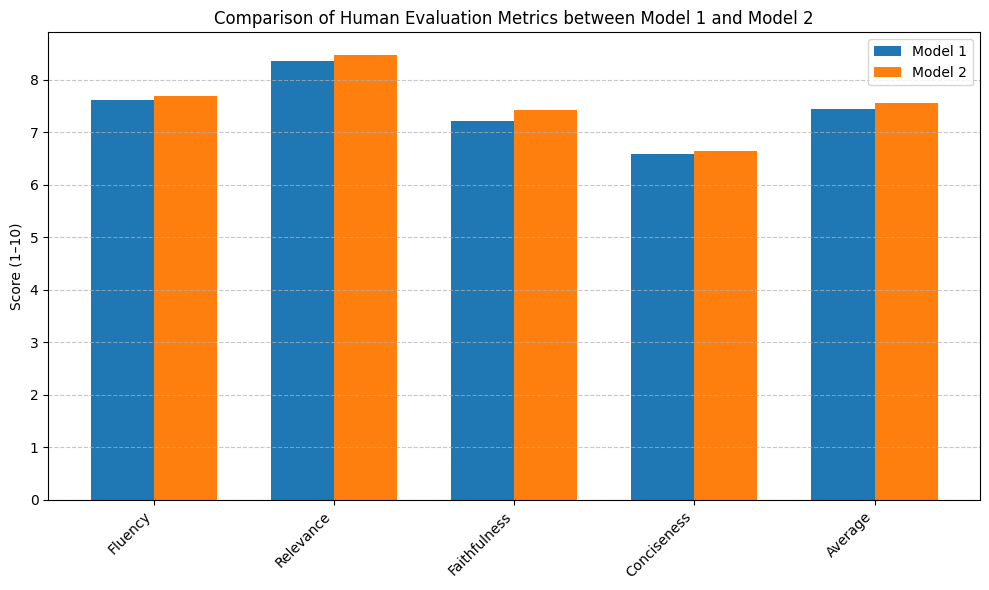

In [73]:
# Dữ liệu human eval
human_data = {
    "Metric": ["Fluency", "Relevance", "Faithfulness", "Conciseness", "Average"],
    "Model 1": [7.6100, 8.3500, 7.2200, 6.5900, 7.4375],
    "Model 2": [7.690, 8.480, 7.430, 6.640, 7.555]
}

df_human = pd.DataFrame(human_data)

# ----- Vẽ biểu đồ grouped bar -----
metrics = df_human["Metric"]
x = range(len(metrics))
width = 0.35  # độ rộng cột

fig, ax = plt.subplots(figsize=(10,6))
ax.bar([i - width/2 for i in x], df_human["Model 1"], width, label="Model 1")
ax.bar([i + width/2 for i in x], df_human["Model 2"], width, label="Model 2")

ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=45, ha="right")
ax.set_ylabel("Score (1–10)")
ax.set_title("Comparison of Human Evaluation Metrics between Model 1 and Model 2")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [74]:
trainer.push_to_hub("letri/vit5_text summarization")
trainer_2.push_to_hub("letri/vit5_text summarization_Synthetic Data")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/letri345/output_augmented/commit/fcd7ce13cd6a94b242387fd6b5d29d77a126ef11', commit_message='letri/vit5_text summarization_Synthetic Data', commit_description='', oid='fcd7ce13cd6a94b242387fd6b5d29d77a126ef11', pr_url=None, repo_url=RepoUrl('https://huggingface.co/letri345/output_augmented', endpoint='https://huggingface.co', repo_type='model', repo_id='letri345/output_augmented'), pr_revision=None, pr_num=None)